# Task 1 - Baseline Monocular Depth Estimation on NYU Depth v2

**Local RTX 4060 Ti 8GB | Target: <=1h training | Depth Anything V2 Small (metric, indoor)**

Starting checkpoint: `depth-anything/Depth-Anything-V2-Metric-Indoor-Small-hf` (Hypersim-trained, 20m max; we fine-tune on NYU 0-10m).


## 1. Imports

In [1]:
import os
import io
import csv
import copy
import json
import time
import random
import unittest
from pathlib import Path
from collections import defaultdict
import glob as glob_module

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from transformers import AutoImageProcessor, AutoModelForDepthEstimation

In [2]:
import transformers, datasets
print(f'PyTorch:      {torch.__version__}')
print(f'CUDA avail:   {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU:          {torch.cuda.get_device_name(0)}')
    print(f'VRAM:         {torch.cuda.get_device_properties(0).total_memory/1e9:.2f} GB')
    print(f'Compute cap:  {torch.cuda.get_device_capability(0)}')
print(f'Transformers: {transformers.__version__}')
print(f'Datasets:     {datasets.__version__}')

assert torch.cuda.is_available(), 'CUDA required for training on RTX 4060 Ti.'

PyTorch:      2.6.0+cu124
CUDA avail:   True
GPU:          NVIDIA GeForce RTX 4060 Ti
VRAM:         8.59 GB
Compute cap:  (8, 9)
Transformers: 5.5.3
Datasets:     4.8.4


## 2. Globals

In [3]:
# --- Device ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Model ---
MODEL_CHECKPOINT = 'depth-anything/Depth-Anything-V2-Metric-Indoor-Small-hf'
# DINOv2-S + DPT head, ~25M params. Metric head trained on Hypersim (20m max).
# We fine-tune on NYU: effective range 0-10m.

# --- Dataset paths ---
DATA_ROOT = r'D:\cv\data\nyu_v2'
CHECKPOINT_DIR = r'D:\cv\checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# --- Image dimensions ---
# DepthAnything V2 Small native input is 518x518 (DINOv2 patch_size=14, 518=14*37).
INPUT_SIZE = 518
NYU_HEIGHT = 480
NYU_WIDTH = 640

# Eigen center crop for test-time metrics (standard NYU protocol, 480x640 frame)
EVAL_CROP_TOP = 45
EVAL_CROP_BOTTOM = 471
EVAL_CROP_LEFT = 41
EVAL_CROP_RIGHT = 601

# --- Depth range (meters) ---
MIN_DEPTH = 1e-3
MAX_DEPTH = 10.0  # NYU v2 ceiling

# --- Training budget (calibrated to 1h wall-clock on RTX 4060 Ti 8GB) ---
# Probe: 383ms/iter @ bs=6 (3GB); bs=12 was SLOWER per-sample (memory-bound).
# Sticking with bs=6. 15K subset x 3 epochs = ~48min train, fits in 55min budget.
TRAIN_SUBSET_SIZE = 15000
BATCH_SIZE = 6
NUM_EPOCHS = 3
WARMUP_EPOCHS = 1
LR_BACKBONE = 5e-6
LR_HEAD = 5e-5
WEIGHT_DECAY = 1e-2
GRAD_CLIP_NORM = 1.0
SILOG_VARIANCE_FOCUS = 0.5

# Wall-clock guard (seconds) - abort training if exceeded
TIME_BUDGET_SEC = 55 * 60

# --- Reproducibility ---
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f'DEVICE:            {DEVICE}')
print(f'MODEL:             {MODEL_CHECKPOINT}')
print(f'DATA_ROOT:         {DATA_ROOT}')
print(f'INPUT_SIZE:        {INPUT_SIZE}x{INPUT_SIZE}')
print(f'TRAIN_SUBSET_SIZE: {TRAIN_SUBSET_SIZE}')
print(f'BATCH_SIZE:        {BATCH_SIZE}  |  EPOCHS: {NUM_EPOCHS}  |  TIME_BUDGET: {TIME_BUDGET_SEC//60}m')
print(f'LR_backbone:       {LR_BACKBONE}  |  LR_head: {LR_HEAD}')
print(f'SEED:              {SEED}')

DEVICE:            cuda
MODEL:             depth-anything/Depth-Anything-V2-Metric-Indoor-Small-hf
DATA_ROOT:         D:\cv\data\nyu_v2
INPUT_SIZE:        518x518
TRAIN_SUBSET_SIZE: 15000
BATCH_SIZE:        6  |  EPOCHS: 3  |  TIME_BUDGET: 55m
LR_backbone:       5e-06  |  LR_head: 5e-05
SEED:              42


In [4]:
class TestGlobals(unittest.TestCase):
    def test_depth_range(self):
        self.assertGreater(MIN_DEPTH, 0)
        self.assertEqual(MAX_DEPTH, 10.0)
        self.assertGreater(MAX_DEPTH, MIN_DEPTH)
    def test_input_size_patch_aligned(self):
        self.assertEqual(INPUT_SIZE % 14, 0, 'INPUT_SIZE must be multiple of DINOv2 patch_size=14')
    def test_eval_crop_valid(self):
        self.assertGreater(EVAL_CROP_BOTTOM - EVAL_CROP_TOP, 0)
        self.assertGreater(EVAL_CROP_RIGHT - EVAL_CROP_LEFT, 0)
        self.assertLessEqual(EVAL_CROP_BOTTOM, NYU_HEIGHT)
        self.assertLessEqual(EVAL_CROP_RIGHT, NYU_WIDTH)
    def test_training_params(self):
        self.assertGreater(BATCH_SIZE, 0)
        self.assertGreater(NUM_EPOCHS, WARMUP_EPOCHS)
        self.assertGreater(LR_HEAD, LR_BACKBONE)
    def test_paths_exist(self):
        self.assertTrue(os.path.isdir(CHECKPOINT_DIR))
_r = unittest.TextTestRunner(verbosity=0, stream=open(os.devnull, 'w')).run(
    unittest.TestLoader().loadTestsFromTestCase(TestGlobals))
assert _r.wasSuccessful(), f'Globals tests failed: {_r.failures + _r.errors}'
print('Globals: OK')

Globals: OK


## 3. Utils

In [5]:
class SILogLoss(nn.Module):
    """Scale-Invariant Logarithmic Loss (Eigen 2014).

    L = sqrt( mean(d^2) - lambda * mean(d)^2 ),  d = log(pred) - log(gt)
    over valid pixels only.
    """
    def __init__(self, variance_focus: float = 0.5):
        super().__init__()
        self.variance_focus = variance_focus

    def forward(self, pred, gt, valid_mask=None):
        if valid_mask is None:
            valid_mask = (gt > MIN_DEPTH) & (gt < MAX_DEPTH)
        valid_mask = valid_mask.bool()
        pred_v = pred[valid_mask].clamp(min=MIN_DEPTH)
        gt_v   = gt[valid_mask].clamp(min=MIN_DEPTH)
        if pred_v.numel() == 0:
            return torch.tensor(0.0, device=pred.device, requires_grad=True)
        d = torch.log(pred_v) - torch.log(gt_v)
        return torch.sqrt(torch.mean(d ** 2) - self.variance_focus * (torch.mean(d) ** 2) + 1e-12)

In [6]:
class TestSILogLoss(unittest.TestCase):
    def setUp(self):
        self.loss_fn = SILogLoss(variance_focus=SILOG_VARIANCE_FOCUS)
    def test_identical_zero(self):
        gt = torch.tensor([1.0, 2.0, 5.0, 8.0]); pred = gt.clone()
        self.assertLess(self.loss_fn(pred, gt).item(), 1e-4)
    def test_positive_on_diff(self):
        gt = torch.tensor([1.0, 2.0, 5.0, 8.0]); pred = torch.tensor([1.5, 3.0, 4.0, 6.0])
        self.assertGreater(self.loss_fn(pred, gt).item(), 0.0)
    def test_gradients_flow(self):
        pred = torch.tensor([1.5, 3.0, 4.0], requires_grad=True); gt = torch.tensor([1.0, 2.0, 5.0])
        self.loss_fn(pred, gt).backward()
        self.assertIsNotNone(pred.grad); self.assertFalse(torch.all(pred.grad == 0))
    def test_mask_excludes_invalid(self):
        gt = torch.tensor([1.0, 2.0, 0.0, 5.0]); pred = torch.tensor([1.0, 2.0, 999.0, 5.0])
        mask = torch.tensor([True, True, False, True])
        self.assertLess(self.loss_fn(pred, gt, valid_mask=mask).item(), 1e-4)
    def test_scale_invariance(self):
        # Pure multiplicative shift should give near-zero loss (variance_focus=1.0 -> fully scale-invariant)
        fn = SILogLoss(variance_focus=1.0)
        gt = torch.tensor([1.0, 2.0, 4.0, 8.0]); pred = gt * 3.0
        self.assertLess(fn(pred, gt).item(), 1e-4)
_r = unittest.TextTestRunner(verbosity=0, stream=open(os.devnull, 'w')).run(
    unittest.TestLoader().loadTestsFromTestCase(TestSILogLoss))
assert _r.wasSuccessful(), f'SILog tests failed: {_r.failures + _r.errors}'
print('SILogLoss: OK')

SILogLoss: OK


In [7]:
def compute_depth_metrics(pred, gt, min_depth=MIN_DEPTH, max_depth=MAX_DEPTH, eigen_crop: bool = False):
    """Compute 8 standard NYU depth metrics over valid pixels.

    Args:
        pred, gt: shape (B, H, W) or (H, W), depth in meters
        eigen_crop: if True, crop to standard NYU Eigen region (assumes 480x640 inputs)
    Returns dict with: abs_rel, sq_rel, rmse, rmse_log, log10, delta1, delta2, delta3
    """
    pred = pred.detach().float()
    gt = gt.detach().float()
    if eigen_crop:
        # pred/gt shape (..., H=480, W=640)
        pred = pred[..., EVAL_CROP_TOP:EVAL_CROP_BOTTOM, EVAL_CROP_LEFT:EVAL_CROP_RIGHT]
        gt   = gt[...,   EVAL_CROP_TOP:EVAL_CROP_BOTTOM, EVAL_CROP_LEFT:EVAL_CROP_RIGHT]

    valid = (gt > min_depth) & (gt < max_depth)
    pred_v = pred[valid].clamp(min=min_depth, max=max_depth)
    gt_v = gt[valid]
    if gt_v.numel() == 0:
        return {k: 0.0 for k in ('abs_rel','sq_rel','rmse','rmse_log','log10','delta1','delta2','delta3')}

    abs_diff = (pred_v - gt_v).abs()
    ratio = torch.max(pred_v / gt_v, gt_v / pred_v)
    return {
        'abs_rel':  (abs_diff / gt_v).mean().item(),
        'sq_rel':   ((abs_diff ** 2) / gt_v).mean().item(),
        'rmse':     torch.sqrt((abs_diff ** 2).mean()).item(),
        'rmse_log': torch.sqrt(((torch.log(pred_v) - torch.log(gt_v)) ** 2).mean()).item(),
        'log10':    (torch.log10(pred_v) - torch.log10(gt_v)).abs().mean().item(),
        'delta1':   (ratio < 1.25   ).float().mean().item(),
        'delta2':   (ratio < 1.25**2).float().mean().item(),
        'delta3':   (ratio < 1.25**3).float().mean().item(),
    }

In [8]:
class TestMetrics(unittest.TestCase):
    def test_perfect(self):
        gt = torch.tensor([[1.0, 2.0], [3.0, 5.0]]); pred = gt.clone()
        m = compute_depth_metrics(pred, gt)
        self.assertAlmostEqual(m['abs_rel'], 0.0, places=5)
        self.assertAlmostEqual(m['rmse'], 0.0, places=5)
        self.assertAlmostEqual(m['delta1'], 1.0, places=5)
    def test_2x_offset(self):
        gt = torch.tensor([[1.0, 2.0], [3.0, 4.0]]); pred = gt * 2.0
        m = compute_depth_metrics(pred, gt)
        self.assertAlmostEqual(m['abs_rel'], 1.0, places=3)
        self.assertAlmostEqual(m['delta1'], 0.0, places=5)
        self.assertAlmostEqual(m['delta3'], 0.0, places=5)
    def test_mask_invalid_zero(self):
        gt = torch.tensor([[1.0, 0.0], [5.0, 15.0]])   # 0 and 15 are invalid
        pred = torch.tensor([[1.0, 999.0], [5.0, 999.0]])
        m = compute_depth_metrics(pred, gt, min_depth=0.001, max_depth=10.0)
        self.assertAlmostEqual(m['abs_rel'], 0.0, places=5)
    def test_eigen_crop(self):
        gt = torch.ones(480, 640) * 2.0
        pred = torch.ones(480, 640) * 2.0
        # Outside Eigen region, pad with garbage -> metric must ignore
        pred[:20, :] = 100.0; pred[:, :20] = 100.0
        m = compute_depth_metrics(pred, gt, eigen_crop=True)
        self.assertAlmostEqual(m['delta1'], 1.0, places=5)
_r = unittest.TextTestRunner(verbosity=0, stream=open(os.devnull, 'w')).run(
    unittest.TestLoader().loadTestsFromTestCase(TestMetrics))
assert _r.wasSuccessful(), f'Metrics tests failed: {_r.failures + _r.errors}'
print('Metrics: OK')

Metrics: OK


In [9]:
def load_depth_map(path, max_depth=MAX_DEPTH):
    """Load NYU v2 depth PNG and convert to meters.
    Supports uint8 (0..255 -> 0..max_depth) and uint16 (mm -> m).
    """
    depth_raw = np.array(Image.open(path))
    if depth_raw.dtype == np.uint8:
        return depth_raw.astype(np.float32) / 255.0 * max_depth
    return depth_raw.astype(np.float32) / 1000.0


def visualize_depth_prediction(rgb, pred, gt, title=''):
    """4-panel visualization: RGB | Pred | GT | |Pred-GT|"""
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    if isinstance(rgb, torch.Tensor):
        rgb = rgb.detach().cpu().permute(1, 2, 0).numpy()
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
    axes[0].imshow(rgb); axes[0].set_title('RGB'); axes[0].axis('off')
    if isinstance(pred, torch.Tensor): pred = pred.detach().cpu().numpy()
    if isinstance(gt, torch.Tensor):   gt = gt.detach().cpu().numpy()
    im1 = axes[1].imshow(pred, cmap='plasma', vmin=0, vmax=MAX_DEPTH)
    axes[1].set_title('Predicted'); axes[1].axis('off'); plt.colorbar(im1, ax=axes[1], fraction=0.046)
    im2 = axes[2].imshow(gt, cmap='plasma', vmin=0, vmax=MAX_DEPTH)
    axes[2].set_title('Ground Truth'); axes[2].axis('off'); plt.colorbar(im2, ax=axes[2], fraction=0.046)
    err = np.abs(pred - gt); err[gt <= MIN_DEPTH] = 0
    im3 = axes[3].imshow(err, cmap='hot', vmin=0, vmax=2.0)
    axes[3].set_title('|Pred - GT|'); axes[3].axis('off'); plt.colorbar(im3, ax=axes[3], fraction=0.046)
    if title: fig.suptitle(title, fontsize=14)
    plt.tight_layout(); plt.show()


def plot_training_curves(train_losses, val_losses, metrics_history):
    epochs = range(1, len(train_losses) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(epochs, train_losses, 'b-o', label='Train')
    axes[0].plot(epochs, val_losses,   'r-o', label='Val')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('SILog Loss')
    axes[0].set_title('Train / Val Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(epochs, [m['abs_rel'] for m in metrics_history], 'g-o')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AbsRel')
    axes[1].set_title('Abs Relative Error'); axes[1].grid(True, alpha=0.3)
    axes[2].plot(epochs, [m['delta1'] for m in metrics_history], 'm-o')
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('delta1')
    axes[2].set_title('Threshold Acc delta<1.25'); axes[2].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

print('Visualization + loader utilities defined.')

Visualization + loader utilities defined.


In [10]:
def verify_gradient_flow(model, sample_input, device=None):
    """Confirm gradients propagate from output depth back to input pixels.
    CRITICAL for Task 2 (adversarial patch crafting).
    Returns True if non-zero input gradient observed.
    """
    device = device or DEVICE
    model.eval()
    x = sample_input.clone().detach().to(device).requires_grad_(True)
    out = model(pixel_values=x)
    pred = out.predicted_depth if hasattr(out, 'predicted_depth') else out[0]
    pred.sum().backward()
    ok = (x.grad is not None) and (not torch.all(x.grad == 0))
    if ok:
        g = x.grad.abs()
        print(f'  input grad: min={g.min():.2e} max={g.max():.2e} mean={g.mean():.2e}')
    else:
        print('  WARNING: no gradient flow to input!')
    model.zero_grad()
    return ok

print('verify_gradient_flow defined.')

verify_gradient_flow defined.


## 4. Data

In [11]:
def discover_nyu_pairs(data_root):
    """Discover NYU v2 (rgb, depth) pairs from Kaggle soumikrakshit layout.

    Primary: CSV-driven (nyu2_train.csv / nyu2_test.csv).
    Fallback: filename matching on *_colors.png / *_depth.png.
    Returns: (train_pairs, test_pairs) list of (rgb_path, depth_path).
    """
    data_root = str(data_root)
    csv_files = sorted(glob_module.glob(os.path.join(data_root, '**', '*.csv'), recursive=True))

    if csv_files:
        train_pairs, test_pairs = [], []
        for csv_path in csv_files:
            csv_dir = os.path.dirname(csv_path)
            with open(csv_path, 'r') as f:
                rows = list(csv.reader(f))
            pairs = []
            for row in rows:
                if len(row) < 2:
                    continue
                rgb_rel = row[0].strip().lstrip('/')
                dep_rel = row[1].strip().lstrip('/')
                resolved = False
                for base in (csv_dir, data_root, os.path.dirname(csv_dir)):
                    rp = os.path.join(base, rgb_rel)
                    dp = os.path.join(base, dep_rel)
                    if os.path.exists(rp) and os.path.exists(dp):
                        pairs.append((rp, dp)); resolved = True; break
                    parts_r = rgb_rel.split('/', 1); parts_d = dep_rel.split('/', 1)
                    if len(parts_r) > 1:
                        rp2 = os.path.join(base, parts_r[1]); dp2 = os.path.join(base, parts_d[1])
                        if os.path.exists(rp2) and os.path.exists(dp2):
                            pairs.append((rp2, dp2)); resolved = True; break
            name = os.path.basename(csv_path).lower()
            if 'test' in name:
                test_pairs = pairs
            else:
                train_pairs = pairs
            print(f'  {os.path.basename(csv_path)}: {len(rows)} rows -> {len(pairs)} resolved pairs')
        if train_pairs:
            return train_pairs, test_pairs

    # Fallback: filename matching
    all_pngs = sorted(glob_module.glob(os.path.join(data_root, '**', '*.png'), recursive=True))
    rgb_list = [p for p in all_pngs if 'colors' in os.path.basename(p).lower()]
    dep_map = {os.path.basename(p).replace('_depth', '_colors'): p
               for p in all_pngs if 'depth' in os.path.basename(p).lower()}
    pairs = [(r, dep_map[os.path.basename(r)]) for r in rgb_list if os.path.basename(r) in dep_map]
    if pairs:
        split = int(0.97 * len(pairs))
        return pairs[:split], pairs[split:]
    raise RuntimeError(f'No NYU pairs discovered in {data_root}. Check dataset layout.')


train_pairs, test_pairs = discover_nyu_pairs(DATA_ROOT)
print(f'\nTrain pairs: {len(train_pairs)}')
print(f'Test  pairs: {len(test_pairs)}')
print(f'Sample:      {train_pairs[0]}')

  nyu2_test.csv: 654 rows -> 654 resolved pairs

  nyu2_train.csv: 50688 rows -> 50688 resolved pairs

Train pairs: 50688
Test  pairs: 654
Sample:      ('D:\\cv\\data\\nyu_v2\\nyu_data\\data\\nyu2_train/living_room_0038_out/37.jpg', 'D:\\cv\\data\\nyu_v2\\nyu_data\\data\\nyu2_train/living_room_0038_out/37.png')


In [12]:
# Sanity: expected split sizes for NYU Depth v2 (DenseDepth / soumikrakshit)
# Train ~50K frames (dense), Test 654.  Tolerate variation in exact counts.
assert len(train_pairs) > 10000, f'Train set too small: {len(train_pairs)}'
assert 500 <= len(test_pairs) <= 1000, f'Test set size odd: {len(test_pairs)}'
assert all(os.path.exists(p[0]) and os.path.exists(p[1]) for p in train_pairs[:10])
assert all(os.path.exists(p[0]) and os.path.exists(p[1]) for p in test_pairs[:10])
print(f'Dataset discovery: OK  (train={len(train_pairs)} test={len(test_pairs)})')

Dataset discovery: OK  (train=50688 test=654)


In [13]:
# Load HF image processor once. Model is loaded later in Section 5.
image_processor = AutoImageProcessor.from_pretrained(MODEL_CHECKPOINT)
print(f'Processor: {type(image_processor).__name__}')
print(f'  do_resize: {image_processor.do_resize}')
print(f'  size:      {image_processor.size}')
print(f'  mean:      {image_processor.image_mean}')
print(f'  std:       {image_processor.image_std}')

Processor: DPTImageProcessor
  do_resize: True
  size:      SizeDict(height=518, width=518, longest_edge=None, shortest_edge=None, max_height=None, max_width=None)
  mean:      (0.485, 0.456, 0.406)
  std:       (0.229, 0.224, 0.225)


In [14]:
class NYUDepthDataset(Dataset):
    """PyTorch Dataset for NYU Depth v2 (rgb_path, depth_path) pairs.

    Returns per sample:
      pixel_values: [3, H, W] processed for the model (H=W=INPUT_SIZE)
      depth_gt:     [1, H, W] metric depth in meters (resized to model input dims)
      valid_mask:   [1, H, W] True where depth in (MIN_DEPTH, MAX_DEPTH)
      depth_original: [1, 480, 640] un-resized depth (for Eigen-crop eval, only if keep_original=True)
      rgb_original:   [3, 480, 640] un-resized RGB uint8 (visualization, only if keep_original=True)

    Notes:
      HF DepthAnything processor preserves aspect ratio by default, so we resize to a square
      INPUT_SIZExINPUT_SIZE ourselves (PIL BICUBIC for RGB, F.interpolate nearest for depth)
      and pass do_resize=False to the processor to only use its normalize step.
    """
    def __init__(self, rgb_paths, depth_paths, processor, input_size=INPUT_SIZE,
                 augment=False, keep_original=False):
        assert len(rgb_paths) == len(depth_paths)
        self.rgb_paths = rgb_paths
        self.depth_paths = depth_paths
        self.processor = processor
        self.input_size = input_size
        self.augment = augment
        self.keep_original = keep_original

    def __len__(self):
        return len(self.rgb_paths)

    def __getitem__(self, idx):
        image = Image.open(self.rgb_paths[idx]).convert('RGB')
        depth_np = load_depth_map(self.depth_paths[idx])

        # Augmentation: horizontal flip only (paper-consistent for DA-V2)
        if self.augment and random.random() > 0.5:
            image = image.transpose(Image.FLIP_LEFT_RIGHT)
            depth_np = np.fliplr(depth_np).copy()

        # Force square resize (bypass processor's aspect-ratio-preserving logic)
        image_square = image.resize((self.input_size, self.input_size), Image.BICUBIC)
        # Use processor only for rescale + normalize
        inputs = self.processor(images=image_square, return_tensors='pt',
                                do_resize=False, do_rescale=True, do_normalize=True)
        pixel_values = inputs['pixel_values'].squeeze(0)  # [3, H, W]

        # Resize depth GT to match (nearest to avoid mixing depths)
        d_t = torch.from_numpy(depth_np).unsqueeze(0).unsqueeze(0).float()
        d_resized = F.interpolate(d_t, size=(self.input_size, self.input_size),
                                  mode='nearest').squeeze(0)  # [1, H, W]
        valid_mask = (d_resized > MIN_DEPTH) & (d_resized < MAX_DEPTH)

        out = {'pixel_values': pixel_values, 'depth_gt': d_resized, 'valid_mask': valid_mask}
        if self.keep_original:
            out['depth_original'] = torch.from_numpy(depth_np).unsqueeze(0).float()  # [1, 480, 640]
            # Resize original image back to NYU canonical 480x640 for visualization consistency
            img_canon = image.resize((NYU_WIDTH, NYU_HEIGHT), Image.BICUBIC)
            out['rgb_original'] = torch.from_numpy(np.array(img_canon)).permute(2, 0, 1)  # [3, 480, 640] uint8
        return out

In [15]:
class TestNYUDepthDataset(unittest.TestCase):
    @classmethod
    def setUpClass(cls):
        rgb = [p[0] for p in train_pairs[:4]]
        dep = [p[1] for p in train_pairs[:4]]
        cls.ds = NYUDepthDataset(rgb, dep, image_processor, augment=False)
        cls.ds_aug = NYUDepthDataset(rgb, dep, image_processor, augment=True)
        cls.ds_orig = NYUDepthDataset(rgb, dep, image_processor, augment=False, keep_original=True)
    def test_len(self):
        self.assertEqual(len(self.ds), 4)
    def test_shapes(self):
        s = self.ds[0]
        self.assertEqual(s['pixel_values'].shape, (3, INPUT_SIZE, INPUT_SIZE))
        self.assertEqual(s['depth_gt'].shape, (1, INPUT_SIZE, INPUT_SIZE))
        self.assertEqual(s['valid_mask'].shape, (1, INPUT_SIZE, INPUT_SIZE))
    def test_depth_range(self):
        s = self.ds[0]
        valid = s['valid_mask'].bool()
        d = s['depth_gt'][valid]
        self.assertTrue((d > MIN_DEPTH).all())
        self.assertTrue((d < MAX_DEPTH).all())
        self.assertGreater(d.max().item(), 1.0, 'Max depth <1m suggests wrong decoding')
    def test_pixel_normalized(self):
        s = self.ds[0]
        self.assertEqual(s['pixel_values'].dtype, torch.float32)
        self.assertLess(s['pixel_values'].abs().max().item(), 10.0)
    def test_augmentation_valid(self):
        s = self.ds_aug[0]
        self.assertFalse(torch.isnan(s['pixel_values']).any())
        self.assertFalse(torch.isnan(s['depth_gt']).any())
    def test_keep_original(self):
        s = self.ds_orig[0]
        self.assertIn('depth_original', s); self.assertIn('rgb_original', s)
        self.assertEqual(s['depth_original'].shape, (1, NYU_HEIGHT, NYU_WIDTH))
        self.assertEqual(s['rgb_original'].shape, (3, NYU_HEIGHT, NYU_WIDTH))
_r = unittest.TextTestRunner(verbosity=0, stream=open(os.devnull, 'w')).run(
    unittest.TestLoader().loadTestsFromTestCase(TestNYUDepthDataset))
assert _r.wasSuccessful(), f'Dataset tests failed: {_r.failures + _r.errors}'
print('NYUDepthDataset: OK')

NYUDepthDataset: OK


In [ ]:
# Subsample training set to fit 1h wall-clock budget (seeded for reproducibility).
random.seed(SEED)
if TRAIN_SUBSET_SIZE is not None and len(train_pairs) > TRAIN_SUBSET_SIZE:
    train_sub = random.sample(train_pairs, TRAIN_SUBSET_SIZE)
    print(f'Subsampled train: {len(train_pairs)} -> {len(train_sub)} pairs')
else:
    train_sub = train_pairs
    print(f'Using full train: {len(train_sub)} pairs')

train_rgb = [p[0] for p in train_sub]
train_dep = [p[1] for p in train_sub]
test_rgb  = [p[0] for p in test_pairs]
test_dep  = [p[1] for p in test_pairs]

train_dataset = NYUDepthDataset(train_rgb, train_dep, image_processor, augment=True)
val_dataset   = NYUDepthDataset(test_rgb,  test_dep,  image_processor, augment=False, keep_original=True)


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f'Train: {len(train_dataset)} samples -> {len(train_loader)} batches (bs={BATCH_SIZE})')
print(f'Val:   {len(val_dataset)} samples -> {len(val_loader)} batches (bs=4)')

# Verify first batch loads correctly
_b = next(iter(train_loader))
print(f'\nBatch shapes:')
for k, v in _b.items():
    print(f'  {k}: {tuple(v.shape)} ({v.dtype})')

Subsampled train: 50688 -> 15000 pairs
Train: 15000 samples -> 2500 batches (bs=6)
Val:   654 samples -> 164 batches (bs=4)



Batch shapes:
  pixel_values: (6, 3, 518, 518) (torch.float32)
  depth_gt: (6, 1, 518, 518) (torch.float32)
  valid_mask: (6, 1, 518, 518) (torch.bool)


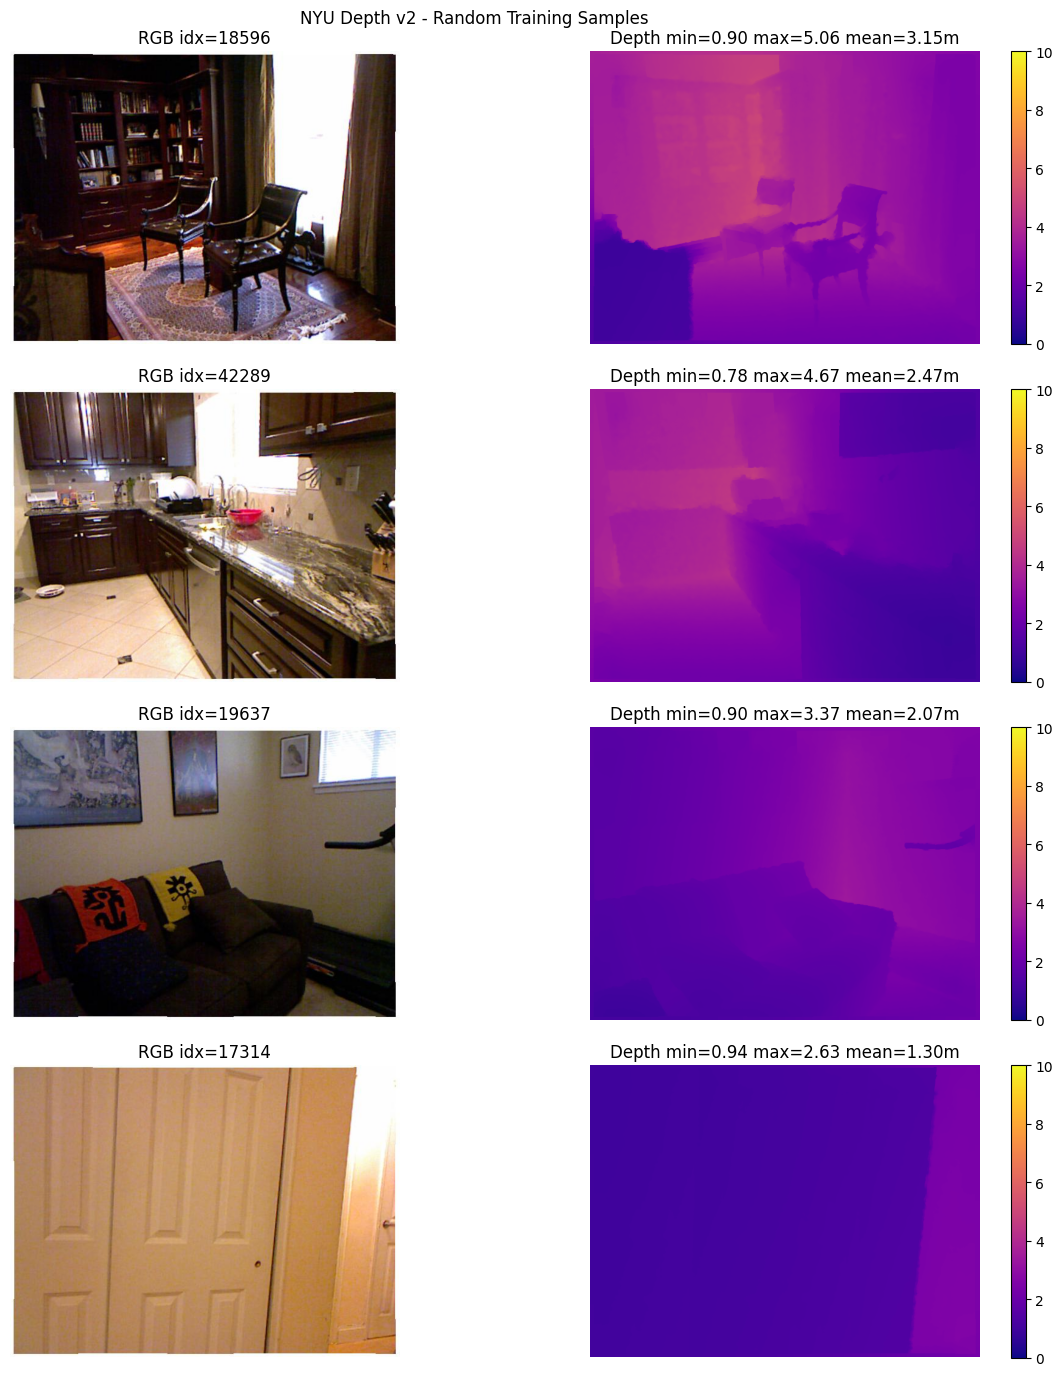

Depth stats over 100 samples:  min=0.706m  max=9.961m  mean=3.459m  median=3.020m  std=1.777m


In [17]:
# Visualize 4 random samples + depth distribution stats across 100 samples
fig, axes = plt.subplots(4, 2, figsize=(12, 14))
for i in range(4):
    idx = random.randint(0, len(train_pairs) - 1)
    rgb = Image.open(train_pairs[idx][0]).convert('RGB')
    dep = load_depth_map(train_pairs[idx][1])
    axes[i, 0].imshow(rgb); axes[i, 0].set_title(f'RGB idx={idx}'); axes[i, 0].axis('off')
    im = axes[i, 1].imshow(dep, cmap='plasma', vmin=0, vmax=MAX_DEPTH)
    axes[i, 1].set_title(f'Depth min={dep.min():.2f} max={dep.max():.2f} mean={dep.mean():.2f}m')
    axes[i, 1].axis('off'); plt.colorbar(im, ax=axes[i, 1], fraction=0.046)
plt.suptitle('NYU Depth v2 - Random Training Samples'); plt.tight_layout(); plt.show()

sample_depths = []
for i in range(min(100, len(train_pairs))):
    d = load_depth_map(train_pairs[i][1])
    v = (d > MIN_DEPTH) & (d < MAX_DEPTH)
    sample_depths.append(d[v])
all_d = np.concatenate(sample_depths)
print(f'Depth stats over 100 samples:  min={all_d.min():.3f}m  max={all_d.max():.3f}m  '
      f'mean={all_d.mean():.3f}m  median={np.median(all_d):.3f}m  std={all_d.std():.3f}m')

## 5. Network

In [18]:
# Load pretrained Depth Anything V2 Metric Indoor Small
model = AutoModelForDepthEstimation.from_pretrained(MODEL_CHECKPOINT).to(DEVICE)
print(f'Model:         {MODEL_CHECKPOINT}')
print(f'Class:         {type(model).__name__}')

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params:     {total:,} ({total/1e6:.1f}M)')
print(f'Trainable params: {trainable:,} ({trainable/1e6:.1f}M)')

print('\nTop-level modules:')
for name, module in model.named_children():
    n = sum(p.numel() for p in module.parameters())
    print(f'  {name:24s}  {n:>12,}  ({n/1e6:.2f}M)')

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

Model:         depth-anything/Depth-Anything-V2-Metric-Indoor-Small-hf
Class:         DepthAnythingForDepthEstimation
Total params:     24,785,089 (24.8M)
Trainable params: 24,785,089 (24.8M)

Top-level modules:
  backbone                    22,056,576  (22.06M)
  neck                         2,700,768  (2.70M)
  head                            27,745  (0.03M)


In [19]:
# Forward-pass sanity: output shape and depth range
dummy = torch.randn(2, 3, INPUT_SIZE, INPUT_SIZE, device=DEVICE)
model.eval()
with torch.no_grad():
    out = model(pixel_values=dummy)

pred = out.predicted_depth  # HF DepthAnything returns [B, H, W] (already interpolated to input res)
print(f'Output type:       {type(out).__name__}')
print(f'predicted_depth:   shape={tuple(pred.shape)} dtype={pred.dtype}')
print(f'Output range:      min={pred.min():.3f}  max={pred.max():.3f}  mean={pred.mean():.3f}')
print(f'Device:            {pred.device}')

assert pred.shape[0] == 2, 'Batch dim mismatch'
assert pred.dim() == 3, f'Expected [B, H, W], got {pred.shape}'

Output type:       DepthEstimatorOutput
predicted_depth:   shape=(2, 518, 518) dtype=torch.float32
Output range:      min=0.767  max=1.068  mean=0.929
Device:            cuda:0


In [ ]:
print('Verifying gradient flow from output depth -> input pixels...')
gr_ok = verify_gradient_flow(model, torch.randn(1, 3, INPUT_SIZE, INPUT_SIZE))
assert gr_ok, 'FATAL: gradients do not reach input pixels; Task 2 cannot proceed.'
print('PASS: input pixels are differentiable.')

Verifying gradient flow from output depth -> input pixels...
  input grad: min=1.44e-05 max=8.02e+02 mean=7.75e+00
PASS: input pixels are differentiable.


In [21]:
# Optimizer with differential learning rates:
#   - backbone (DINOv2 encoder, already-rich features) -> LR_BACKBONE
#   - head/decoder/neck (must adapt to NYU depth scale) -> LR_HEAD
backbone_params, head_params = [], []
for name, p in model.named_parameters():
    if 'backbone' in name:
        backbone_params.append(p)
    else:
        head_params.append(p)

optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': LR_BACKBONE},
    {'params': head_params,     'lr': LR_HEAD},
], weight_decay=WEIGHT_DECAY)

print(f'Backbone params:  {sum(p.numel() for p in backbone_params):,}  LR={LR_BACKBONE}')
print(f'Head params:      {sum(p.numel() for p in head_params):,}  LR={LR_HEAD}')
print(f'Weight decay:     {WEIGHT_DECAY}')

Backbone params:  22,056,576  LR=5e-06
Head params:      2,728,513  LR=5e-05
Weight decay:     0.01


In [22]:
class TestModel(unittest.TestCase):
    def test_fwd_shape(self):
        x = torch.randn(1, 3, INPUT_SIZE, INPUT_SIZE, device=DEVICE)
        model.eval()
        with torch.no_grad():
            o = model(pixel_values=x)
        self.assertEqual(o.predicted_depth.dim(), 3)
        self.assertEqual(o.predicted_depth.shape[0], 1)
    def test_fwd_batch(self):
        x = torch.randn(3, 3, INPUT_SIZE, INPUT_SIZE, device=DEVICE)
        model.eval()
        with torch.no_grad():
            o = model(pixel_values=x)
        self.assertEqual(o.predicted_depth.shape[0], 3)
    def test_fwd_positive(self):
        # Metric model should produce non-negative depth (sigmoid * max_depth style head)
        x = torch.randn(1, 3, INPUT_SIZE, INPUT_SIZE, device=DEVICE)
        model.eval()
        with torch.no_grad():
            o = model(pixel_values=x)
        self.assertGreaterEqual(o.predicted_depth.min().item(), 0.0)
    def test_train_eval_modes(self):
        model.train(); self.assertTrue(model.training)
        model.eval();  self.assertFalse(model.training)
    def test_differentiable(self):
        x = torch.randn(1, 3, INPUT_SIZE, INPUT_SIZE, device=DEVICE, requires_grad=True)
        model.eval()
        o = model(pixel_values=x)
        o.predicted_depth.sum().backward()
        self.assertIsNotNone(x.grad)
        model.zero_grad()
_r = unittest.TextTestRunner(verbosity=0, stream=open(os.devnull, 'w')).run(
    unittest.TestLoader().loadTestsFromTestCase(TestModel))
assert _r.wasSuccessful(), f'Model tests failed: {_r.failures + _r.errors}'
print('Model: OK')

Model: OK


## 6. Train

In [23]:
def train_one_epoch(model, loader, optimizer, loss_fn, device, scaler, grad_clip, time_budget_end=None):
    """One training epoch with AMP fp16 + grad-clip.

    time_budget_end: optional time.time()+N; returns early if exceeded.
    Returns (avg_loss, n_batches_run, timed_out).
    """
    model.train()
    total_loss, n = 0.0, 0
    timed_out = False
    for batch in tqdm(loader, desc='Train', leave=False):
        if time_budget_end is not None and time.time() > time_budget_end:
            timed_out = True; break
        pv = batch['pixel_values'].to(device, non_blocking=True)
        gt = batch['depth_gt'].to(device, non_blocking=True)
        vm = batch['valid_mask'].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', dtype=torch.float16):
            out = model(pixel_values=pv)
            pred = out.predicted_depth  # [B, H, W]
            # gt/vm are [B, 1, H, W]; squeeze to match
            loss = loss_fn(pred, gt.squeeze(1), vm.squeeze(1))

        if not torch.isfinite(loss):
            # Skip the bad step; don't corrupt AMP scaler state
            optimizer.zero_grad(set_to_none=True)
            continue

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        n += 1
    return (total_loss / max(n, 1)), n, timed_out


@torch.no_grad()
def validate(model, loader, loss_fn, device, eigen_crop=True):
    """Validation with SILog loss + full metric suite. Uses Eigen crop.

    For Eigen-crop metrics:
      - model predicts at INPUT_SIZE (e.g. 518x518)
      - pred is resized to original NYU (480x640) via bilinear
      - metrics computed after Eigen crop
    """
    model.eval()
    total_loss = 0.0
    agg = defaultdict(float)
    n = 0
    for batch in tqdm(loader, desc='Val', leave=False):
        pv = batch['pixel_values'].to(device, non_blocking=True)
        gt_orig = batch['depth_original'].to(device, non_blocking=True)  # [B, 1, 480, 640]

        out = model(pixel_values=pv)
        pred = out.predicted_depth.unsqueeze(1)  # [B, 1, H, W]
        pred_480 = F.interpolate(pred, size=(NYU_HEIGHT, NYU_WIDTH),
                                 mode='bilinear', align_corners=False).squeeze(1)  # [B, 480, 640]
        gt_480 = gt_orig.squeeze(1)  # [B, 480, 640]

        # Loss computed at training-resolution via F.interpolate of gt (for monitoring consistency)
        gt_at_in = F.interpolate(gt_orig, size=pred.shape[-2:], mode='nearest').squeeze(1)
        vm_at_in = (gt_at_in > MIN_DEPTH) & (gt_at_in < MAX_DEPTH)
        loss = loss_fn(out.predicted_depth, gt_at_in, vm_at_in)
        if torch.isfinite(loss):
            total_loss += loss.item()

        m = compute_depth_metrics(pred_480, gt_480, eigen_crop=eigen_crop)
        for k, v in m.items():
            agg[k] += v
        n += 1
    return (total_loss / max(n, 1)), {k: v / max(n, 1) for k, v in agg.items()}

print('train_one_epoch + validate defined.')

train_one_epoch + validate defined.


In [24]:
# LR scheduler: linear warmup for WARMUP_EPOCHS, then cosine decay to 1e-7
warmup_scheduler = optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, end_factor=1.0,
                                                total_iters=WARMUP_EPOCHS)
cosine_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer,
                                                         T_max=max(NUM_EPOCHS - WARMUP_EPOCHS, 1),
                                                         eta_min=1e-7)
scheduler = optim.lr_scheduler.SequentialLR(optimizer,
                                             schedulers=[warmup_scheduler, cosine_scheduler],
                                             milestones=[WARMUP_EPOCHS])

# AMP scaler for fp16 mixed precision
scaler = torch.amp.GradScaler('cuda')

# SILog loss
loss_fn = SILogLoss(variance_focus=SILOG_VARIANCE_FOCUS)
print('Scheduler, AMP scaler, loss_fn ready.')

Scheduler, AMP scaler, loss_fn ready.


In [25]:
# Overfit sanity: train on 4 samples for 50 iters; loss must decrease.
# Use production differential LR to avoid destabilizing the pretrained head.
print('Overfit sanity check (4 samples, 50 iters)...')
_tiny_rgb = [p[0] for p in train_pairs[:4]]
_tiny_dep = [p[1] for p in train_pairs[:4]]
_tiny_ds = NYUDepthDataset(_tiny_rgb, _tiny_dep, image_processor, augment=False)
_tiny_dl = DataLoader(_tiny_ds, batch_size=4, shuffle=False, num_workers=0)

# Snapshot state so full training starts clean
_orig_model = copy.deepcopy(model.state_dict())

_bb, _hd = [], []
for nm, p in model.named_parameters():
    (_bb if 'backbone' in nm else _hd).append(p)
_t_opt = optim.AdamW([
    {'params': _bb, 'lr': LR_BACKBONE},
    {'params': _hd, 'lr': LR_HEAD * 4},  # slightly higher head LR to overfit 4 samples in 50 iters
], weight_decay=WEIGHT_DECAY)
_t_scaler = torch.amp.GradScaler('cuda')

_losses = []
model.train()
for it in range(50):
    for b in _tiny_dl:
        pv = b['pixel_values'].to(DEVICE); gt = b['depth_gt'].to(DEVICE); vm = b['valid_mask'].to(DEVICE)
        _t_opt.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', dtype=torch.float16):
            o = model(pixel_values=pv)
            l = loss_fn(o.predicted_depth, gt.squeeze(1), vm.squeeze(1))
        if not torch.isfinite(l):
            _t_opt.zero_grad(set_to_none=True); continue
        _t_scaler.scale(l).backward()
        _t_scaler.unscale_(_t_opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        _t_scaler.step(_t_opt)
        _t_scaler.update()
        _losses.append(l.item())
    if (it + 1) % 10 == 0:
        print(f'  iter {it+1:02d}/50  loss={_losses[-1]:.4f}')

print(f'\nInitial loss: {_losses[0]:.4f}  ->  Final loss: {_losses[-1]:.4f}  '
      f'(min seen: {min(_losses):.4f})')
assert min(_losses) < _losses[0], f'Loss never decreased: min {min(_losses):.4f} >= initial {_losses[0]:.4f}'
print('PASS: training pipeline is working (loss decreases on overfit).')

# Restore clean state for full training
model.load_state_dict(_orig_model)
del _orig_model, _bb, _hd, _t_opt, _t_scaler
torch.cuda.empty_cache()
print('State restored for full training.')

Overfit sanity check (4 samples, 50 iters)...


  iter 10/50  loss=0.0862


  iter 20/50  loss=0.0727


  iter 30/50  loss=0.0470


  iter 40/50  loss=0.0484


  iter 50/50  loss=0.0482

Initial loss: 0.2405  ->  Final loss: 0.0482  (min seen: 0.0401)
PASS: training pipeline is working (loss decreases on overfit).
State restored for full training.


In [ ]:
print('Throughput probe (20 iters at bs={})...'.format(BATCH_SIZE))
_orig = copy.deepcopy(model.state_dict())

model.train()
torch.cuda.reset_peak_memory_stats()
_times = []
_it = iter(train_loader)
for i in range(22):  # 2 warmup + 20 measured
    b = next(_it)
    pv = b['pixel_values'].to(DEVICE, non_blocking=True)
    gt = b['depth_gt'].to(DEVICE, non_blocking=True)
    vm = b['valid_mask'].to(DEVICE, non_blocking=True)
    torch.cuda.synchronize()
    t0 = time.time()
    optimizer.zero_grad(set_to_none=True)
    with torch.amp.autocast('cuda', dtype=torch.float16):
        o = model(pixel_values=pv)
        l = loss_fn(o.predicted_depth, gt.squeeze(1), vm.squeeze(1))
    scaler.scale(l).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
    scaler.step(optimizer); scaler.update()
    torch.cuda.synchronize()
    if i >= 2:
        _times.append(time.time() - t0)

_mean_s = sum(_times) / len(_times)
_peak_gb = torch.cuda.max_memory_allocated() / 1e9
_batches_total = len(train_loader)
_est_epoch_min = _batches_total * _mean_s / 60
_est_3epoch_min = 3 * _est_epoch_min

print(f'Steady-state: {_mean_s*1000:.0f} ms/iter  ({1/_mean_s:.1f} it/s)')
print(f'Peak VRAM:    {_peak_gb:.2f} GB')
print(f'Estimated 1 epoch: {_est_epoch_min:.1f} min  ({_batches_total} batches)')
print(f'Estimated {NUM_EPOCHS} epochs: {_est_3epoch_min:.1f} min (+ ~{NUM_EPOCHS*0.8:.1f} min val)')
print(f'Time budget: {TIME_BUDGET_SEC//60} min')
if _est_3epoch_min > TIME_BUDGET_SEC / 60 * 0.85:
    print(f'  WARNING: estimated training > 85% of budget. Consider reducing TRAIN_SUBSET_SIZE.')

# Restore state so training starts fresh
model.load_state_dict(_orig)
del _orig
scaler = torch.amp.GradScaler('cuda')  # reset scaler state
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
print('State restored.')

Throughput probe (20 iters at bs=6)...


Steady-state: 378 ms/iter  (2.6 it/s)
Peak VRAM:    3.05 GB
Estimated 1 epoch: 15.8 min  (2500 batches)
Estimated 3 epochs: 47.3 min (+ ~2.4 min val)
Time budget: 55 min
State restored.


In [27]:
# Full training loop with checkpointing + wall-clock guard.
best_abs_rel = float('inf')
train_losses, val_losses, metrics_history = [], [], []

start_time = time.time()
time_budget_end = start_time + TIME_BUDGET_SEC

print(f'Training start: {NUM_EPOCHS} epochs (warmup {WARMUP_EPOCHS}) | bs={BATCH_SIZE} | time budget {TIME_BUDGET_SEC//60}m')
print(f'Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)}')
print('=' * 74)

for epoch in range(NUM_EPOCHS):
    t0 = time.time()
    tr_loss, n_batches, timed_out = train_one_epoch(model, train_loader, optimizer, loss_fn,
                                                     DEVICE, scaler, GRAD_CLIP_NORM,
                                                     time_budget_end=time_budget_end)
    train_losses.append(tr_loss)
    epoch_min = (time.time() - t0) / 60

    # Validate after each epoch
    vl_loss, metrics = validate(model, val_loader, loss_fn, DEVICE, eigen_crop=True)
    val_losses.append(vl_loss)
    metrics_history.append(metrics)

    scheduler.step()
    lr_now = optimizer.param_groups[0]['lr']

    total_min = (time.time() - start_time) / 60
    print(f'Epoch {epoch+1}/{NUM_EPOCHS} | train_loss {tr_loss:.4f} | val_loss {vl_loss:.4f} | '
          f'd1 {metrics["delta1"]:.4f} | AbsRel {metrics["abs_rel"]:.4f} | RMSE {metrics["rmse"]:.3f} | '
          f'lr {lr_now:.2e} | epoch {epoch_min:.1f}m | total {total_min:.1f}m'
          + (' | TIMEOUT' if timed_out else ''))

    # Save best (lowest AbsRel) + latest
    if metrics['abs_rel'] < best_abs_rel:
        best_abs_rel = metrics['abs_rel']
        torch.save({
            'epoch': epoch, 'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'metrics': metrics, 'val_loss': vl_loss,
        }, os.path.join(CHECKPOINT_DIR, 'best_model.pth'))
        print(f'  -> new best AbsRel {best_abs_rel:.4f}, saved best_model.pth')

    torch.save({
        'epoch': epoch, 'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'train_losses': train_losses, 'val_losses': val_losses,
        'metrics_history': metrics_history,
    }, os.path.join(CHECKPOINT_DIR, 'latest.pth'))

    if timed_out or time.time() > time_budget_end:
        print(f'  Time budget reached ({TIME_BUDGET_SEC//60}m), stopping at epoch {epoch+1}.')
        break

print('=' * 74)
print(f'Training complete. Best AbsRel: {best_abs_rel:.4f}. Total: {(time.time()-start_time)/60:.1f}m')

Training start: 3 epochs (warmup 1) | bs=6 | time budget 55m
Train samples: 15000 | Val samples: 654


Train:   0%|          | 0/2500 [00:00<?, ?it/s]

Val:   0%|          | 0/164 [00:00<?, ?it/s]

D:\cv\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 1/3 | train_loss 0.1326 | val_loss 0.1255 | d1 0.9288 | AbsRel 0.0912 | RMSE 0.368 | lr 5.00e-06 | epoch 17.1m | total 17.5m


...

Train:   0%|          | 0/2500 [00:00<?, ?it/s]

Val:   0%|          | 0/164 [00:00<?, ?it/s]

Epoch 3/3 | train_loss 0.0857 | val_loss 0.1185 | d1 0.9351 | AbsRel 0.0897 | RMSE 0.349 | lr 1.00e-07 | epoch 10.2m | total 38.4m


  -> new best AbsRel 0.0897, saved best_model.pth


Training complete. Best AbsRel: 0.0897. Total: 38.5m


## 7. Evaluation

In [28]:
# Load best checkpoint for final evaluation
_best_path = os.path.join(CHECKPOINT_DIR, 'best_model.pth')
_ckpt = torch.load(_best_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(_ckpt['model_state_dict'])
model.eval()
print(f'Loaded best checkpoint:  epoch {_ckpt["epoch"] + 1}  val_loss {_ckpt["val_loss"]:.4f}')
print(f'Stored val metrics:')
for k, v in _ckpt['metrics'].items():
    print(f'  {k:10s}  {v:.4f}')

Loaded best checkpoint:  epoch 3  val_loss 0.1185
Stored val metrics:
  abs_rel     0.0897
  sq_rel      0.0432
  rmse        0.3493
  rmse_log    0.1210
  log10       0.0378
  delta1      0.9351
  delta2      0.9897
  delta3      0.9978


In [ ]:
# Full test-set evaluation with Eigen crop + save metrics.json
final_val_loss, final_metrics = validate(model, val_loader, loss_fn, DEVICE, eigen_crop=True)

print(f'\n=== Final NYU Depth v2 Test-Set Metrics (Eigen crop) ===')
print(f'  val_loss  {final_val_loss:.4f}')
print(f'  delta1    {final_metrics["delta1"]:.4f}  (higher is better)')
print(f'  delta2    {final_metrics["delta2"]:.4f}')
print(f'  delta3    {final_metrics["delta3"]:.4f}')
print(f'  abs_rel   {final_metrics["abs_rel"]:.4f}  (lower is better)')
print(f'  sq_rel    {final_metrics["sq_rel"]:.4f}')
print(f'  rmse      {final_metrics["rmse"]:.4f} m')
print(f'  rmse_log  {final_metrics["rmse_log"]:.4f}')
print(f'  log10     {final_metrics["log10"]:.4f}')

_meta = {
    'model': MODEL_CHECKPOINT,
    'input_size': INPUT_SIZE,
    'min_depth': MIN_DEPTH, 'max_depth': MAX_DEPTH,
    'train_subset_size': TRAIN_SUBSET_SIZE,
    'batch_size': BATCH_SIZE,
    'num_epochs_ran': len(train_losses),
    'lr_backbone': LR_BACKBONE, 'lr_head': LR_HEAD,
    'silog_variance_focus': SILOG_VARIANCE_FOCUS,
    'seed': SEED,
    'eigen_crop': [EVAL_CROP_TOP, EVAL_CROP_BOTTOM, EVAL_CROP_LEFT, EVAL_CROP_RIGHT],
    'val_loss': final_val_loss,
    'metrics': final_metrics,
}
_json_path = os.path.join(CHECKPOINT_DIR, 'baseline_metrics.json')
with open(_json_path, 'w') as f:
    json.dump(_meta, f, indent=2)
print(f'\nSaved: {_json_path}')

Val:   0%|          | 0/164 [00:00<?, ?it/s]


=== Final NYU Depth v2 Test-Set Metrics (Eigen crop) ===
  val_loss  0.1185
  delta1    0.9351  (higher is better)
  delta2    0.9897
  delta3    0.9978
  abs_rel   0.0897  (lower is better)
  sq_rel    0.0432
  rmse      0.3493 m
  rmse_log  0.1210
  log10     0.0378

Saved: D:\cv\checkpoints\baseline_metrics.json


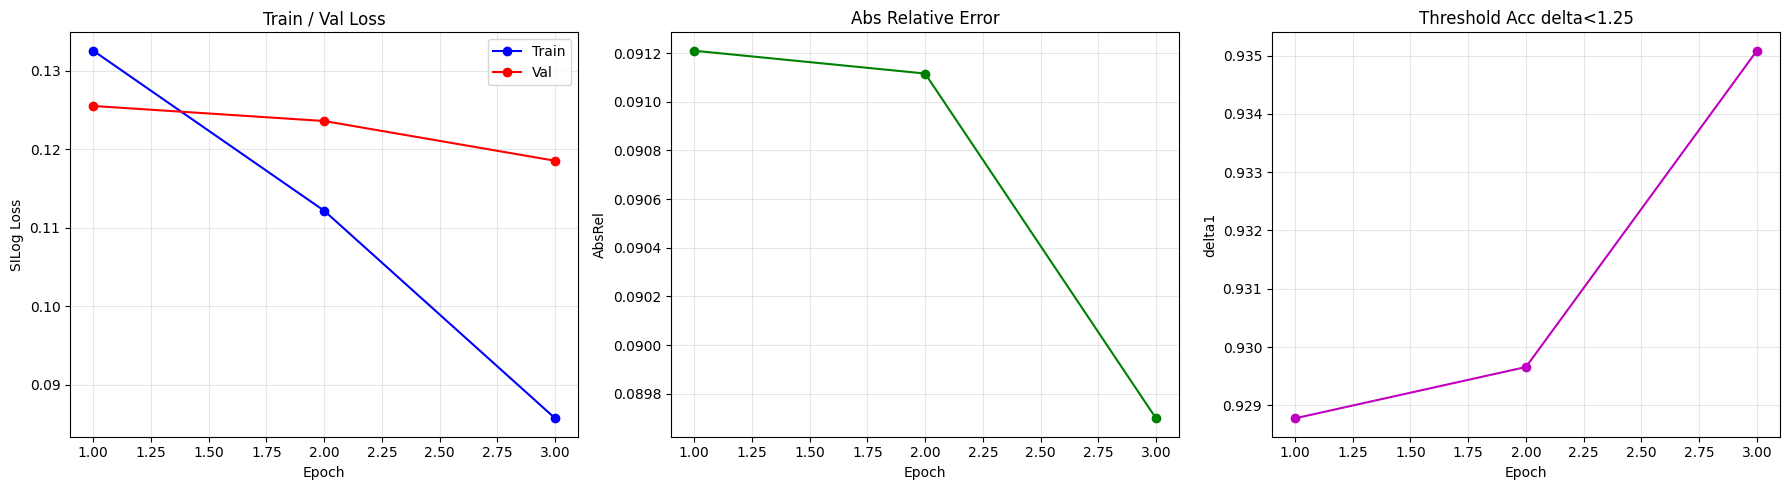

In [30]:
# Training curves
plot_training_curves(train_losses, val_losses, metrics_history)

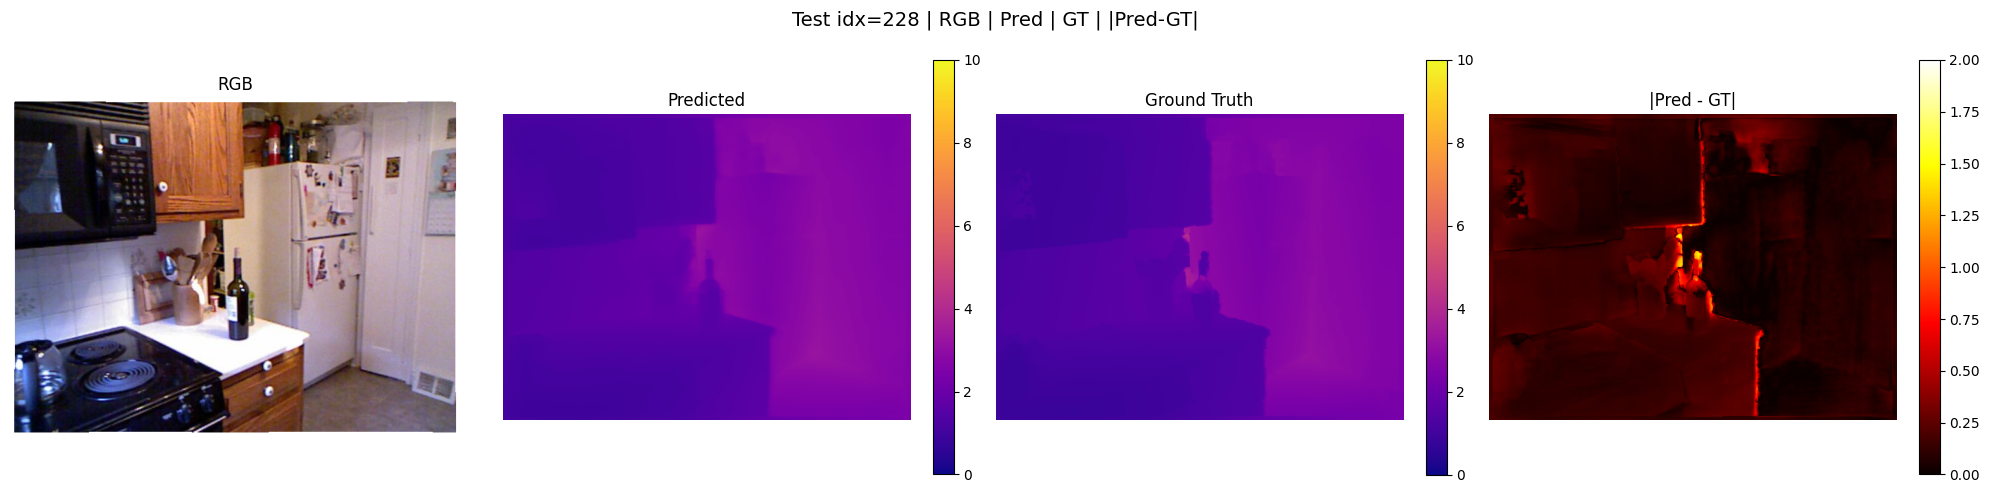

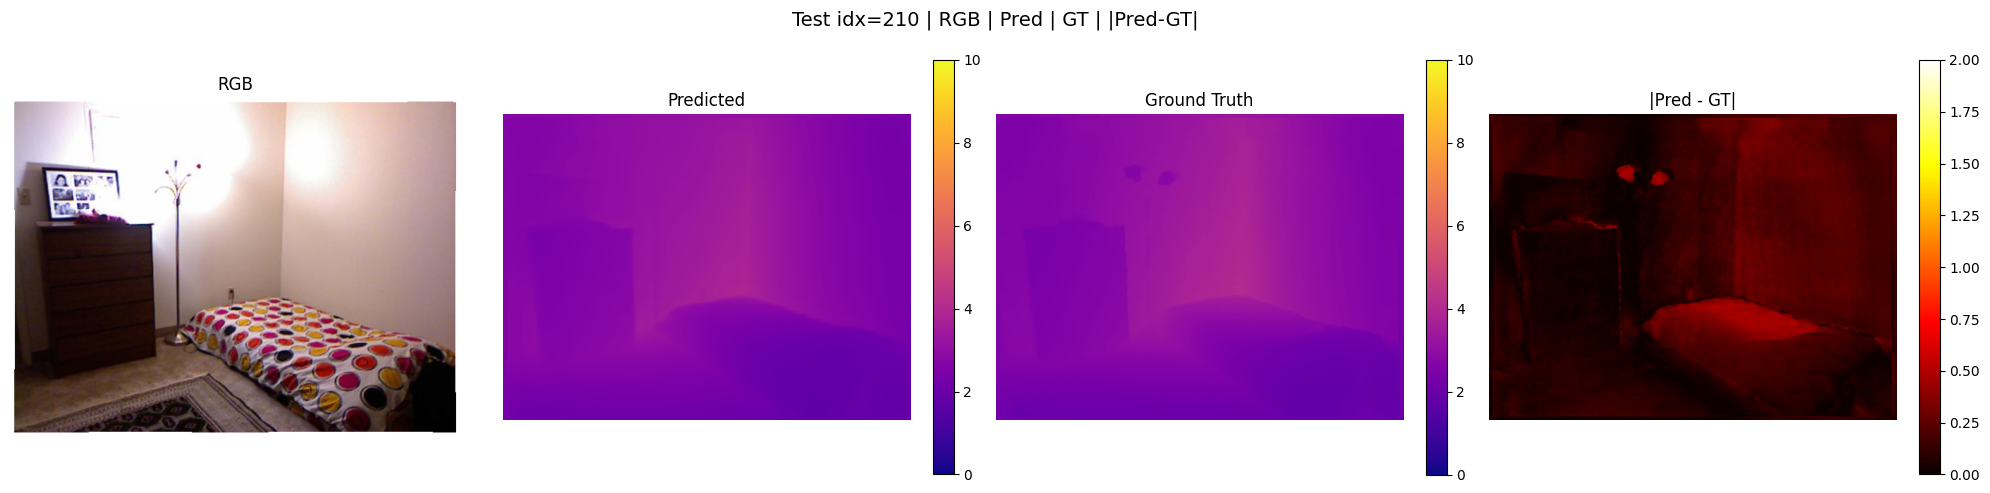

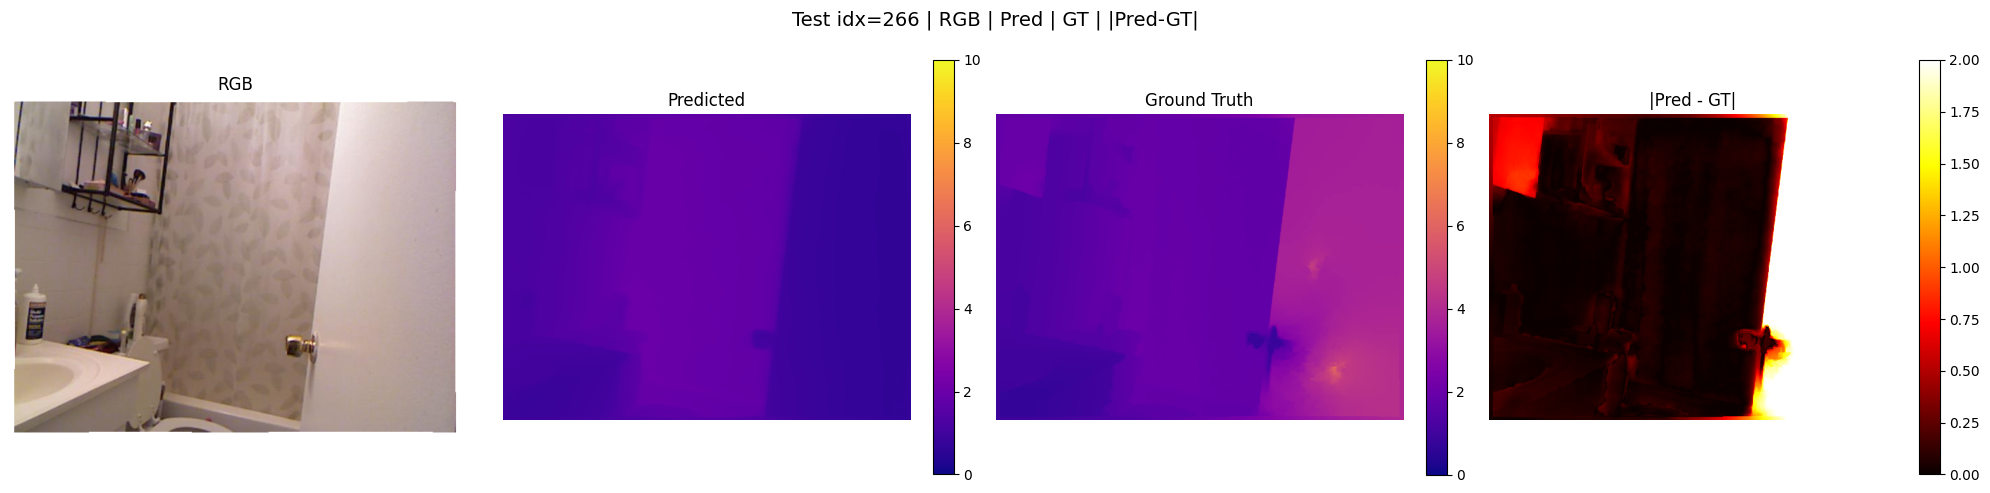

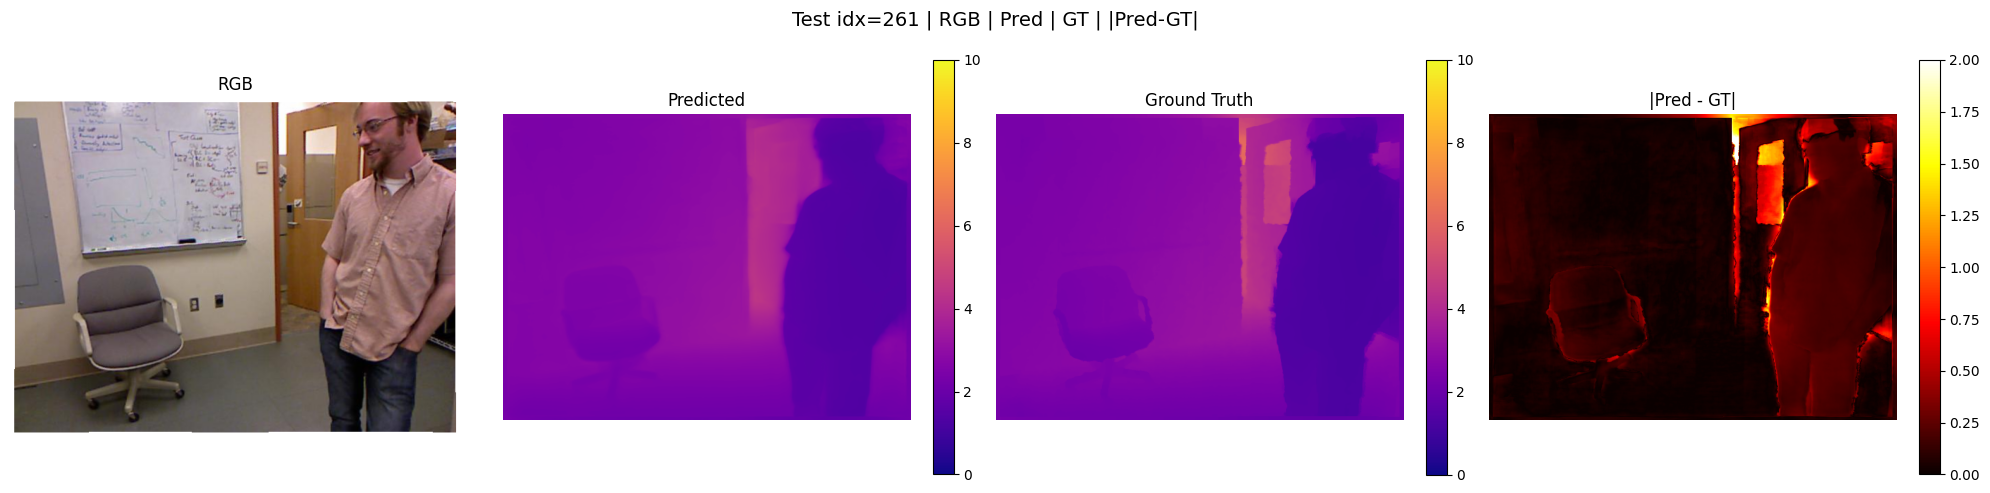

In [31]:
# Qualitative: visualize 4 predictions on the test set
model.eval()
_viz_indices = random.sample(range(len(val_dataset)), 4)
with torch.no_grad():
    for idx in _viz_indices:
        sample = val_dataset[idx]
        pv = sample['pixel_values'].unsqueeze(0).to(DEVICE)
        out = model(pixel_values=pv)
        pred = out.predicted_depth  # [1, H, W]
        pred_480 = F.interpolate(pred.unsqueeze(1), size=(NYU_HEIGHT, NYU_WIDTH),
                                 mode='bilinear', align_corners=False).squeeze(1).squeeze(0)
        gt_480 = sample['depth_original'].squeeze(0)  # [480, 640]
        rgb = sample['rgb_original'].float() / 255.0
        visualize_depth_prediction(rgb, pred_480.cpu(), gt_480,
                                   title=f'Test idx={idx} | RGB | Pred | GT | |Pred-GT|')

In [32]:
# Compare against expected baseline targets
_acceptance = {
    'delta1': (0.90, 0.95),   # (minimum, target)
    'abs_rel': (0.12, 0.08),  # (maximum, target)
    'rmse':    (0.40, 0.30),
}
print('Acceptance summary:')
for k, (mn_or_mx, target) in _acceptance.items():
    v = final_metrics[k]
    ok = (v >= mn_or_mx) if k == 'delta1' else (v <= mn_or_mx)
    reach_target = (v >= target) if k == 'delta1' else (v <= target)
    status = 'TARGET' if reach_target else ('PASS' if ok else 'FAIL')
    print(f'  {k:8s} {v:.4f}  [{status}]  (min/max={mn_or_mx}, target={target})')

print(f'\nFinal artifacts:')
print(f'  {os.path.join(CHECKPOINT_DIR, "best_model.pth")}')
print(f'  {os.path.join(CHECKPOINT_DIR, "latest.pth")}')
print(f'  {os.path.join(CHECKPOINT_DIR, "baseline_metrics.json")}')

Acceptance summary:
  delta1   0.9351  [PASS]  (min/max=0.9, target=0.95)
  abs_rel  0.0897  [PASS]  (min/max=0.12, target=0.08)
  rmse     0.3493  [PASS]  (min/max=0.4, target=0.3)

Final artifacts:
  D:\cv\checkpoints\best_model.pth
  D:\cv\checkpoints\latest.pth
  D:\cv\checkpoints\baseline_metrics.json
